In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

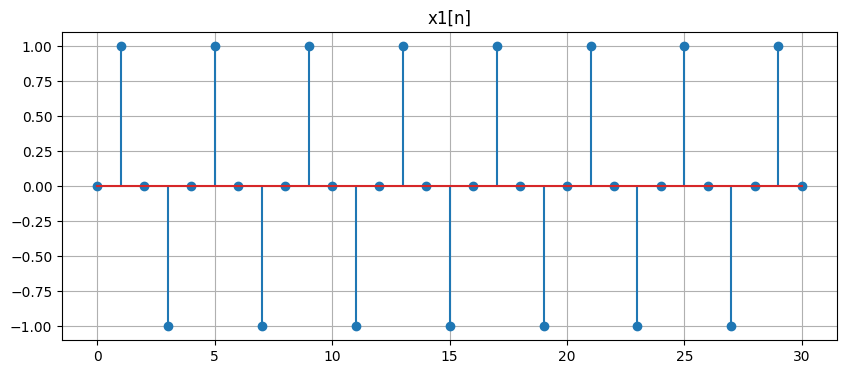

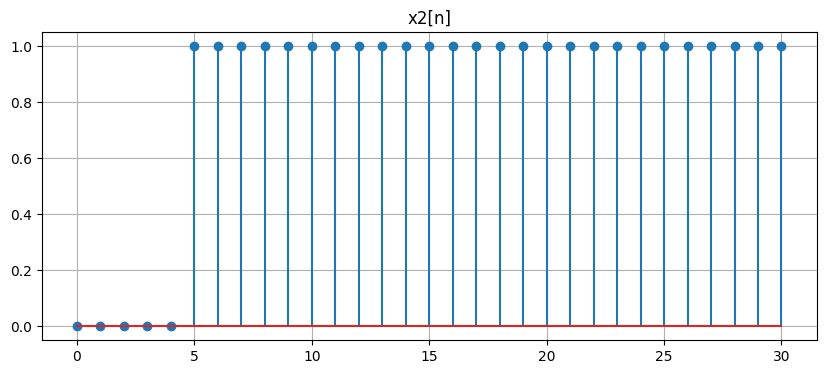

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0,31)

x1 = np.sin(0.5*np.pi*n)
x2 = np.where(n>=5,1,0)

plt.figure(figsize=(10,4))
plt.stem(n,x1)
plt.title('x1[n]')
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.stem(n,x2)
plt.title('x2[n]')
plt.grid()
plt.show()

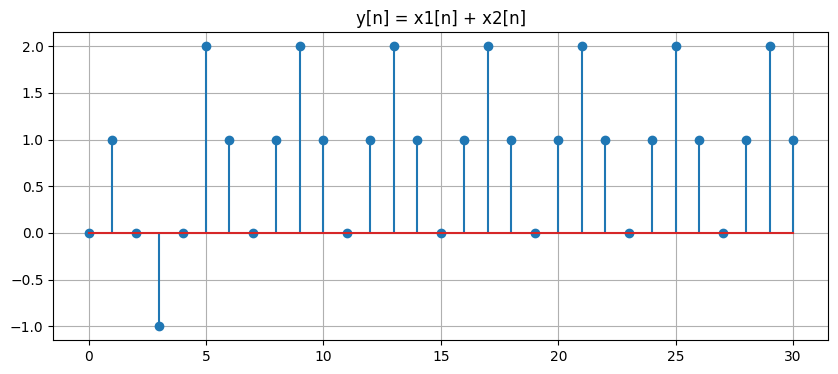

In [3]:
y = x1 + x2

plt.figure(figsize=(10,4))
plt.stem(n,y)
plt.title('y[n] = x1[n] + x2[n]')
plt.grid()
plt.show()

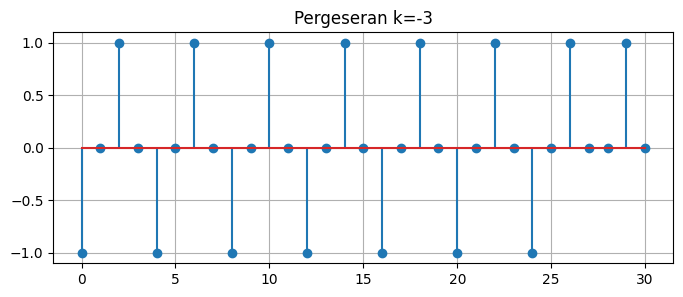

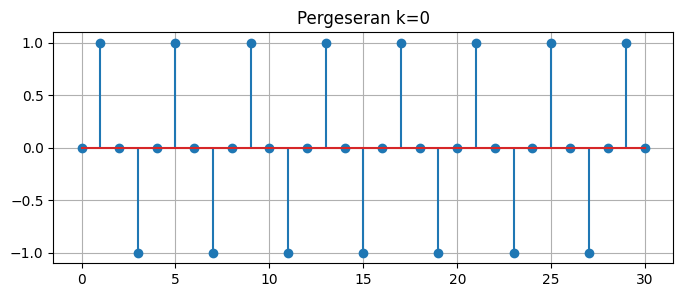

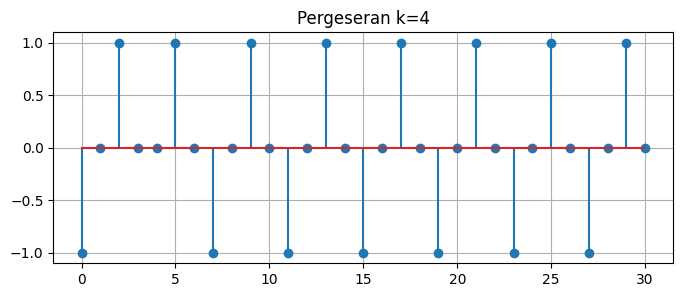

In [4]:
k_values = [-3,0,4]

for k in k_values:
    y_shift = np.roll(x1,k)

    plt.figure(figsize=(8,3))
    plt.stem(n,y_shift)
    plt.title(f'Pergeseran k={k}')
    plt.grid()
    plt.show()

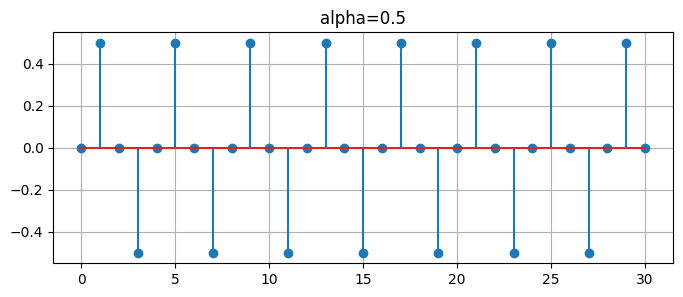

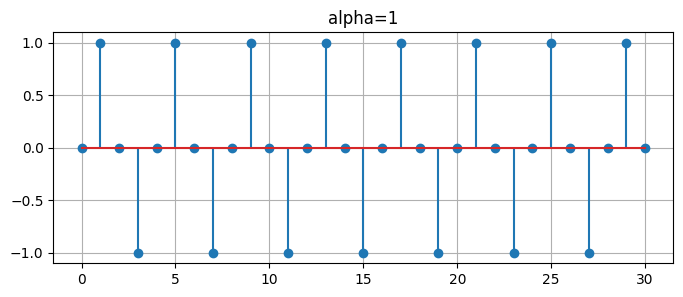

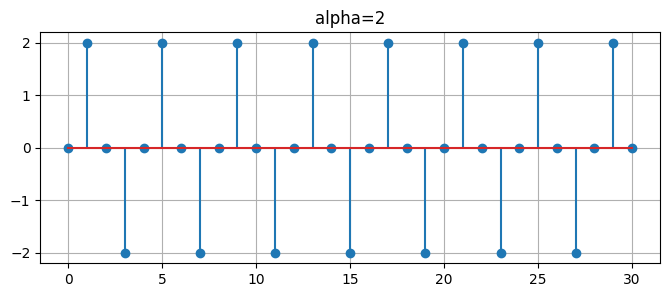

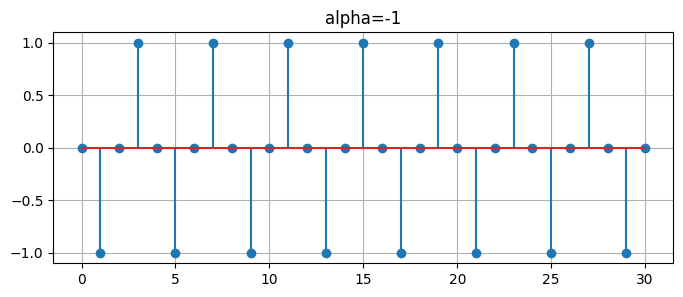

In [5]:
alpha_list = [0.5,1,2,-1]

for alpha in alpha_list:

    y_amp = alpha*x1

    plt.figure(figsize=(8,3))
    plt.stem(n,y_amp)
    plt.title(f'alpha={alpha}')
    plt.grid()
    plt.show()

In [9]:
from google.colab import files

uploaded = files.upload()

Saving gambar.jpg to gambar.jpg


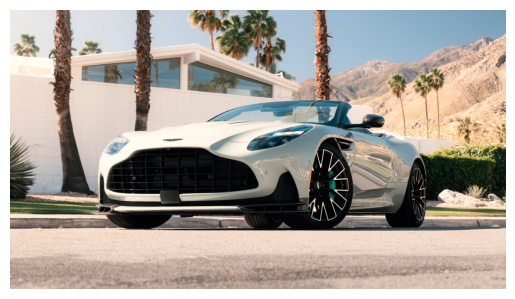

In [10]:
img = cv2.imread('gambar.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

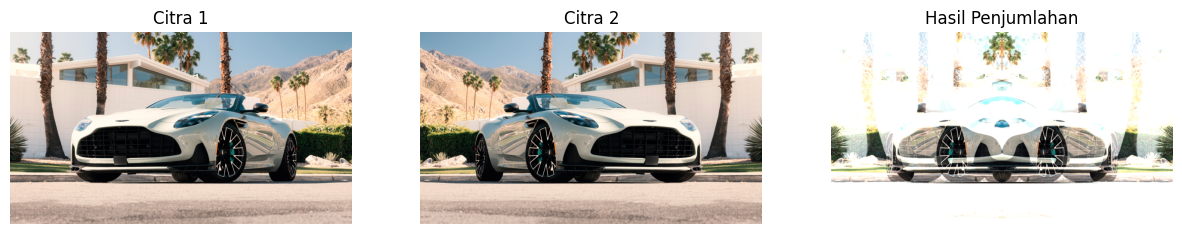

In [11]:
img1 = img.copy()

img2 = cv2.flip(img1, 1)

if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

hasil_tambah = cv2.add(img1, img2)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img1)
plt.title("Citra 1")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2)
plt.title("Citra 2")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_tambah)
plt.title("Hasil Penjumlahan")
plt.axis('off')

plt.show()

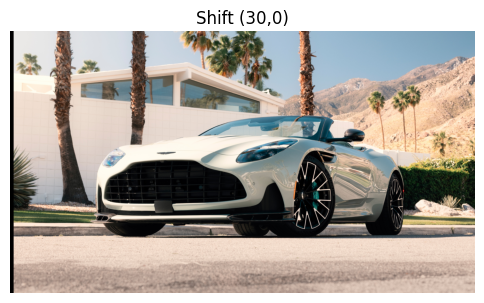

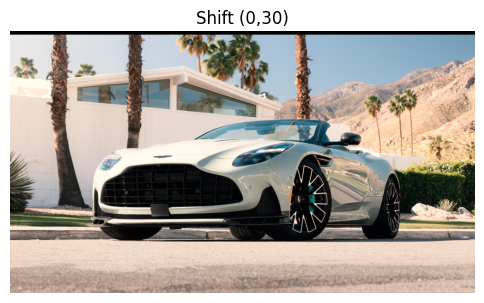

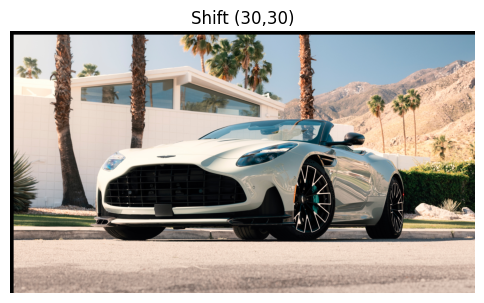

In [12]:
rows, cols = img.shape[:2]

geser = [
    (30,0),
    (0,30),
    (30,30)
]

for dx,dy in geser:

    M = np.float32([
        [1,0,dx],
        [0,1,dy]
    ])

    shifted = cv2.warpAffine(img,M,(cols,rows))

    plt.figure(figsize=(6,6))
    plt.imshow(shifted)
    plt.title(f"Shift ({dx},{dy})")
    plt.axis('off')
    plt.show()

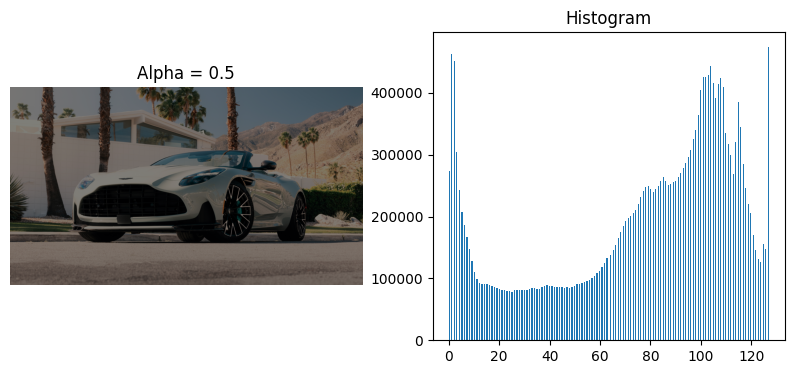

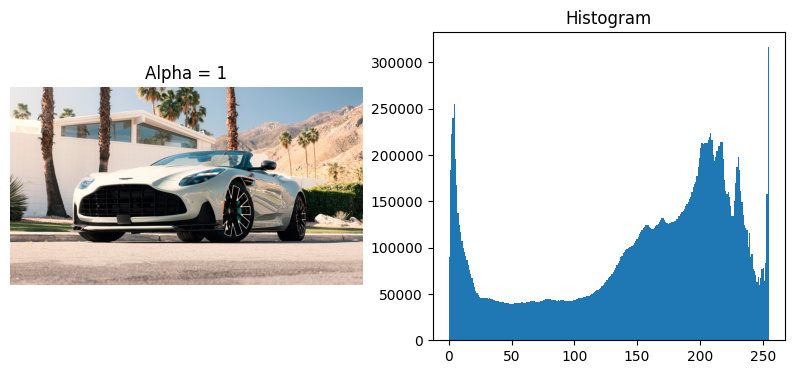

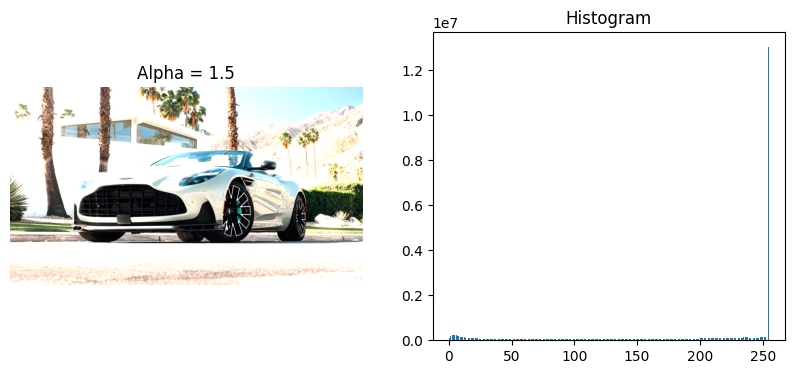

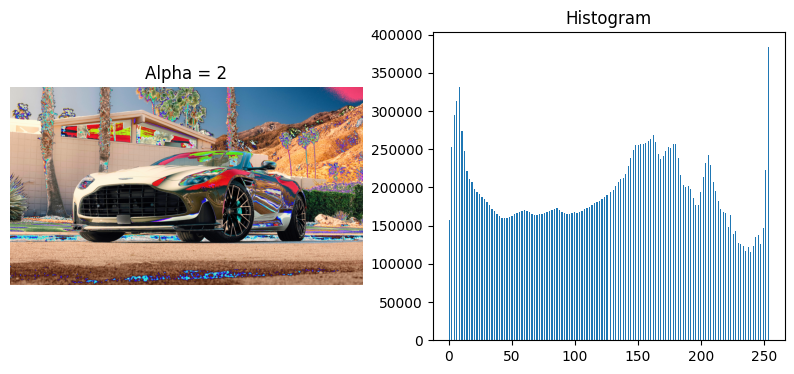

In [13]:
alpha_values = [0.5,1,1.5,2]

for alpha in alpha_values:

    bright = np.clip(alpha*img,0,255).astype(np.uint8)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(bright)
    plt.title(f'Alpha = {alpha}')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.hist(bright.ravel(), bins=256)
    plt.title('Histogram')

    plt.show()

In [14]:
def T(x):
    return 2*x

In [15]:
alpha_list = [0.5,2,3]

for alpha in alpha_list:

    kiri = T(alpha*x1)

    kanan = alpha*T(x1)

    print("alpha =",alpha)
    print(np.allclose(kiri,kanan))

alpha = 0.5
True
alpha = 2
True
alpha = 3
True


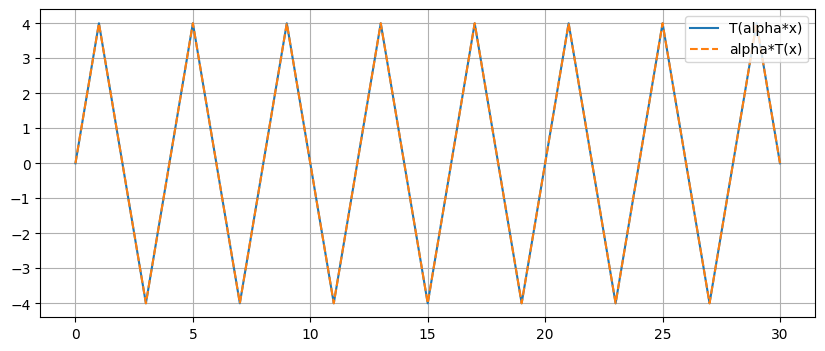

In [16]:
alpha = 2

kiri = T(alpha*x1)
kanan = alpha*T(x1)

plt.figure(figsize=(10,4))

plt.plot(n,kiri,label='T(alpha*x)')
plt.plot(n,kanan,'--',label='alpha*T(x)')

plt.legend()
plt.grid()
plt.show()

In [17]:
left = T(x1+x2)

right = T(x1)+T(x2)

print(np.allclose(left,right))

True


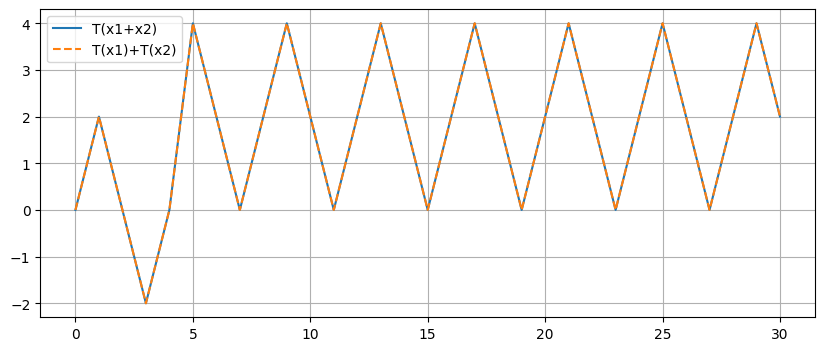

In [18]:
plt.figure(figsize=(10,4))
plt.plot(n,left,label='T(x1+x2)')
plt.plot(n,right,'--',label='T(x1)+T(x2)')
plt.legend()
plt.grid()
plt.show()

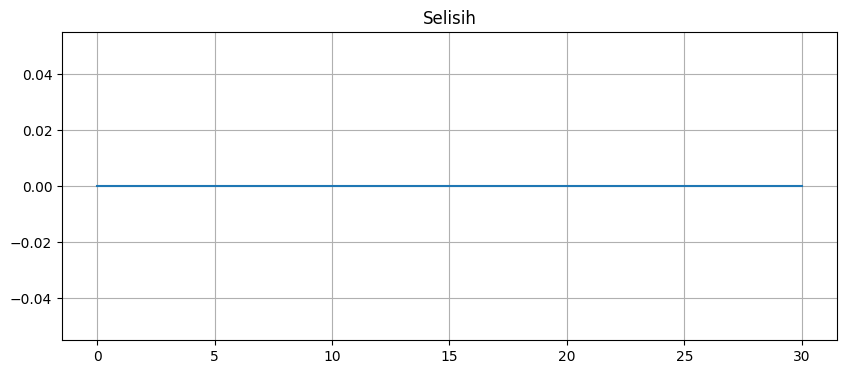

In [19]:
difference = left-right

plt.figure(figsize=(10,4))
plt.plot(n,difference)
plt.title("Selisih")
plt.grid()
plt.show()

In [21]:
def T1(x):
    return 2*x

In [22]:
def T2(x):
    return x**2

In [23]:
left = T2(x1+x2)

right = T2(x1)+T2(x2)

print(np.allclose(left,right))

False


In [24]:
alpha = 2

left = T2(alpha*x1)

right = alpha*T2(x1)

print(np.allclose(left,right))

False
